<a href="https://colab.research.google.com/github/Vishnu912py/time_series_forecasting/blob/main/MSTL%20Decomposition/MSTL(using_electricity_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import MSTL

In [96]:
url = "https://raw.githubusercontent.com/tidyverts/tsibbledata/master/data-raw/vic_elec/VIC2015/demand.csv"
df = pd.read_csv(url)
df

,Date,Period,OperationalLessIndustrial,Industrial
0,37257,1,3535.867064,1086.132936
1,37257,2,3383.499028,1088.500972
2,37257,3,3655.527552,1084.472448
3,37257,4,3510.446636,1085.553364
4,37257,5,3294.697156,1081.302844
...,...,...,...,...
230779,42064,44,NaN,NaN
230780,42064,45,NaN,NaN
230781,42064,46,NaN,NaN
230782,42064,47,NaN,NaN


In [97]:
df["Date"] = df["Date"].apply(
    lambda x: pd.Timestamp("1899-12-30") + pd.Timedelta(x, unit="days")
)

df





,Date,Period,OperationalLessIndustrial,Industrial
0,2002-01-01,1,3535.867064,1086.132936
1,2002-01-01,2,3383.499028,1088.500972
2,2002-01-01,3,3655.527552,1084.472448
3,2002-01-01,4,3510.446636,1085.553364
4,2002-01-01,5,3294.697156,1081.302844
...,...,...,...,...
230779,2015-03-01,44,NaN,NaN
230780,2015-03-01,45,NaN,NaN
230781,2015-03-01,46,NaN,NaN
230782,2015-03-01,47,NaN,NaN


In [98]:
df["ds"] = df["Date"] + pd.to_timedelta((df["Period"] - 1) * 30, unit="m")

In [99]:
df

,Date,Period,OperationalLessIndustrial,Industrial,ds
0,2002-01-01,1,3535.867064,1086.132936,2002-01-01 00:00:00
1,2002-01-01,2,3383.499028,1088.500972,2002-01-01 00:30:00
2,2002-01-01,3,3655.527552,1084.472448,2002-01-01 01:00:00
3,2002-01-01,4,3510.446636,1085.553364,2002-01-01 01:30:00
4,2002-01-01,5,3294.697156,1081.302844,2002-01-01 02:00:00
...,...,...,...,...,...
230779,2015-03-01,44,NaN,NaN,2015-03-01 21:30:00
230780,2015-03-01,45,NaN,NaN,2015-03-01 22:00:00
230781,2015-03-01,46,NaN,NaN,2015-03-01 22:30:00
230782,2015-03-01,47,NaN,NaN,2015-03-01 23:00:00


## TRAINING AND SPLITING THE DATA

We cannot use sklearn.model_selection.train_test_split module because the time series has a inherent chronological order(temporal relationships) which is required but if we use train_test_split it will randomly shuffle all the datasets to reduce selection bias.

In [100]:
timeseries = df[["ds", "OperationalLessIndustrial"]]
timeseries.columns = [
    "ds",
    "y",
]  # Rename to OperationalLessIndustrial to y for simplicity.

# Filter for first 149 days of 2012.
start_date = pd.to_datetime("2012-01-01")
end_date = start_date + pd.Timedelta("149D")
mask = (timeseries["ds"] >= start_date) & (timeseries["ds"] < end_date)
timeseries = timeseries[mask]

# Resample to hourly
timeseries = timeseries.set_index("ds").resample("h").sum()

# Split data into training and testing sets
test_size = 24 * 7 * 2 # 2 weeks for testing (hourly data)
train_data = timeseries.iloc[:-test_size]
test_data = timeseries.iloc[-test_size:]

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)
display(train_data.head())
display(test_data.head())

Training data shape: (3240, 1)
Testing data shape: (336, 1)


,y
ds,
2012-01-01 00:00:00,7926.529376
2012-01-01 01:00:00,7901.826990
2012-01-01 02:00:00,7255.721350
2012-01-01 03:00:00,6792.503352
2012-01-01 04:00:00,6635.984460


,y
ds,
2012-05-15 00:00:00,8821.939726
2012-05-15 01:00:00,8815.029322
2012-05-15 02:00:00,8157.569918
2012-05-15 03:00:00,7710.985372
2012-05-15 04:00:00,7637.993618


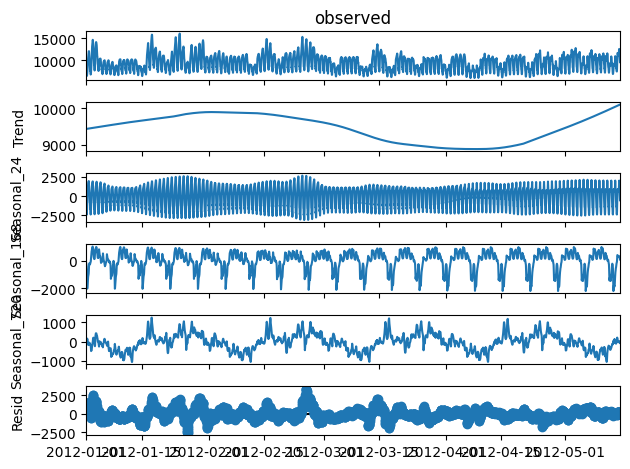

In [101]:
mstl = MSTL(
    train_data["y"],
    periods=[24, 24 * 7, 720],
    iterate=3,
    stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0},
)
res = mstl.fit()  # Use .fit() to perform and return the decomposition
ax = res.plot()
plt.tight_layout()

In [102]:
res

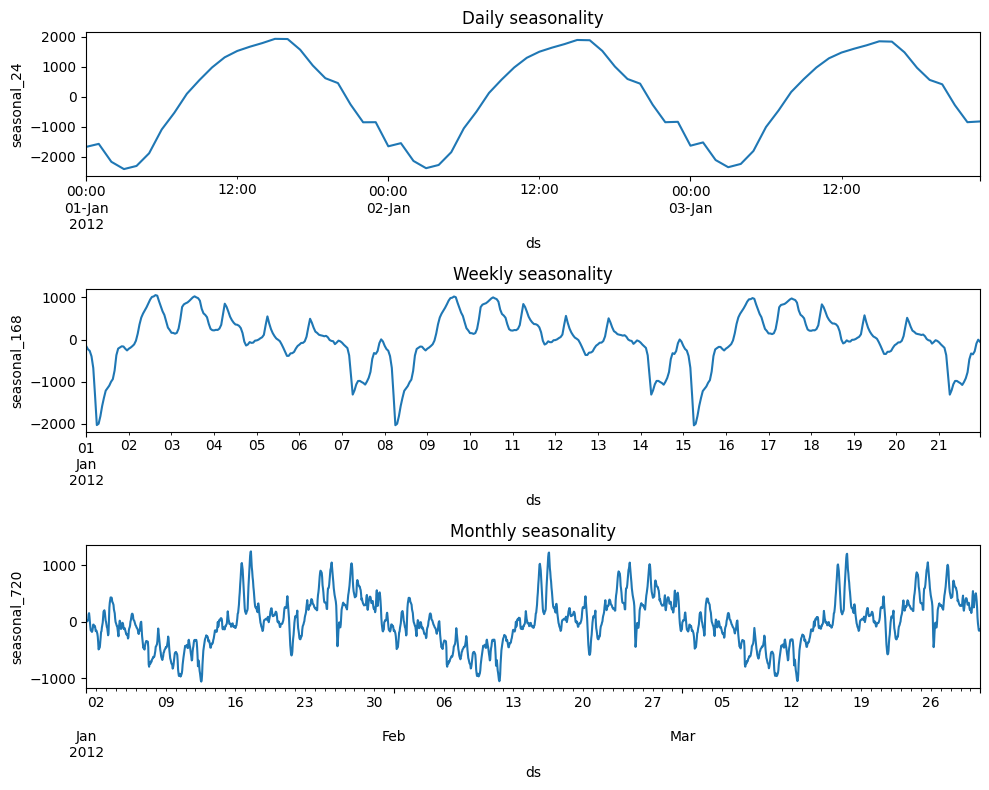

In [103]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=[10, 8])
res.seasonal["seasonal_24"].iloc[: 24 * 3].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_24")
ax[0].set_title("Daily seasonality")

res.seasonal["seasonal_168"].iloc[: 24 * 7 * 3].plot(ax=ax[1])
ax[1].set_ylabel("seasonal_168")
ax[1].set_title("Weekly seasonality")

res.seasonal["seasonal_720"].iloc[: 24 * 30 * 3].plot(ax=ax[2])
ax[2].set_ylabel("seasonal_720")
ax[2].set_title("Monthly seasonality")

plt.tight_layout()
plt.savefig("all_seasonalities.png")

In [104]:
# Get all attributes of the 'res' object
all_attributes = dir(res)

# Separate methods (callable attributes) from other attributes
methods = [attr for attr in all_attributes if callable(getattr(res, attr)) and not attr.startswith('__')]
attributes = [attr for attr in all_attributes if not callable(getattr(res, attr)) and not attr.startswith('__')]

print("Attributes of the 'res' object:")
for attr in sorted(attributes):
    print(f"- {attr}")

print("\nMethods of the 'res' object:")
for method in sorted(methods):
    print(f"- {method}")

Attributes of the 'res' object:
- _observed
- _resid
- _seasonal
- _trend
- _weights
- nobs
- observed
- resid
- seasonal
- trend
- weights

Methods of the 'res' object:
- plot


In [105]:
original_variance = train_data['y'].var()

daily_seasonal_variance = res.seasonal['seasonal_24'].var()
weekly_seasonal_variance = res.seasonal['seasonal_168'].var()
monthly_seasonal_variance = res.seasonal['seasonal_720'].var()

print(f"Original time series variance (train data): {original_variance:.2f}")
print(f"Daily seasonality strength: {daily_seasonal_variance / original_variance:.4f}")
print(f"Weekly seasonality strength: {weekly_seasonal_variance / original_variance:.4f}")
print(f"Monthly seasonality strength: {monthly_seasonal_variance / original_variance:.4f}")

Original time series variance (train data): 3059748.42
Daily seasonality strength: 0.5616
Weekly seasonality strength: 0.1600
Monthly seasonality strength: 0.0576


### Forecasting with MSTL Components

To forecast, we'll individually forecast the trend and residuals, and extend the seasonal components by repeating their patterns. Then, we combine them to get the final forecast.

In [106]:
from statsmodels.tsa.api import ExponentialSmoothing

# Define forecast horizon as the length of the test data
forecast_steps = len(test_data)

# Create a future date index for forecasting (aligns with test_data index)
future_dates = test_data.index

# 1. Forecast the Trend Component using Exponential Smoothing on training data
trend_model = ExponentialSmoothing(res.trend, trend='add', seasonal=None, initialization_method="estimated").fit()
forecasted_trend = trend_model.forecast(forecast_steps)

# 2. Forecast Seasonal Components by repeating the last cycle from training data
def repeat_seasonal(seasonal_component, steps, index):
    period = len(seasonal_component)
    repeated_seasonal = np.tile(seasonal_component, int(np.ceil(steps / period)))[:steps]
    return pd.Series(repeated_seasonal, index=index)

forecasted_seasonal_24 = repeat_seasonal(res.seasonal['seasonal_24'].iloc[-24:], forecast_steps, future_dates)
forecasted_seasonal_168 = repeat_seasonal(res.seasonal['seasonal_168'].iloc[-168:], forecast_steps, future_dates)
forecasted_seasonal_720 = repeat_seasonal(res.seasonal['seasonal_720'].iloc[-720:], forecast_steps, future_dates)

# 3. Forecast Residuals (assume 0 for simplicity, or model them if significant)
forecasted_residuals = pd.Series(0, index=future_dates)

# 4. Combine all components for the final forecast
final_forecast = forecasted_trend + forecasted_seasonal_24 + forecasted_seasonal_168 + forecasted_seasonal_720 + forecasted_residuals

print("Forecasted Trend (first 5):")
display(forecasted_trend.head())
print("Forecasted Daily Seasonality (first 5):")
display(forecasted_seasonal_24.head())
print("Final Forecast (first 5):")
display(final_forecast.head())

Forecasted Trend (first 5):


,0
2012-05-15 00:00:00,10102.090761
2012-05-15 01:00:00,10104.178202
2012-05-15 02:00:00,10106.265643
2012-05-15 03:00:00,10108.353085
2012-05-15 04:00:00,10110.440526


Forecasted Daily Seasonality (first 5):


,0
ds,
2012-05-15 00:00:00,-1334.230585
2012-05-15 01:00:00,-1319.407544
2012-05-15 02:00:00,-1889.743341
2012-05-15 03:00:00,-2296.294857
2012-05-15 04:00:00,-2374.240767


Final Forecast (first 5):


,0
2012-05-15 00:00:00,8744.731028
2012-05-15 01:00:00,8775.008715
2012-05-15 02:00:00,8249.216878
2012-05-15 03:00:00,7868.217270
2012-05-15 04:00:00,7928.079145


### Visualize MSTL (Exponential Smoothing) Forecast vs. Actual Values

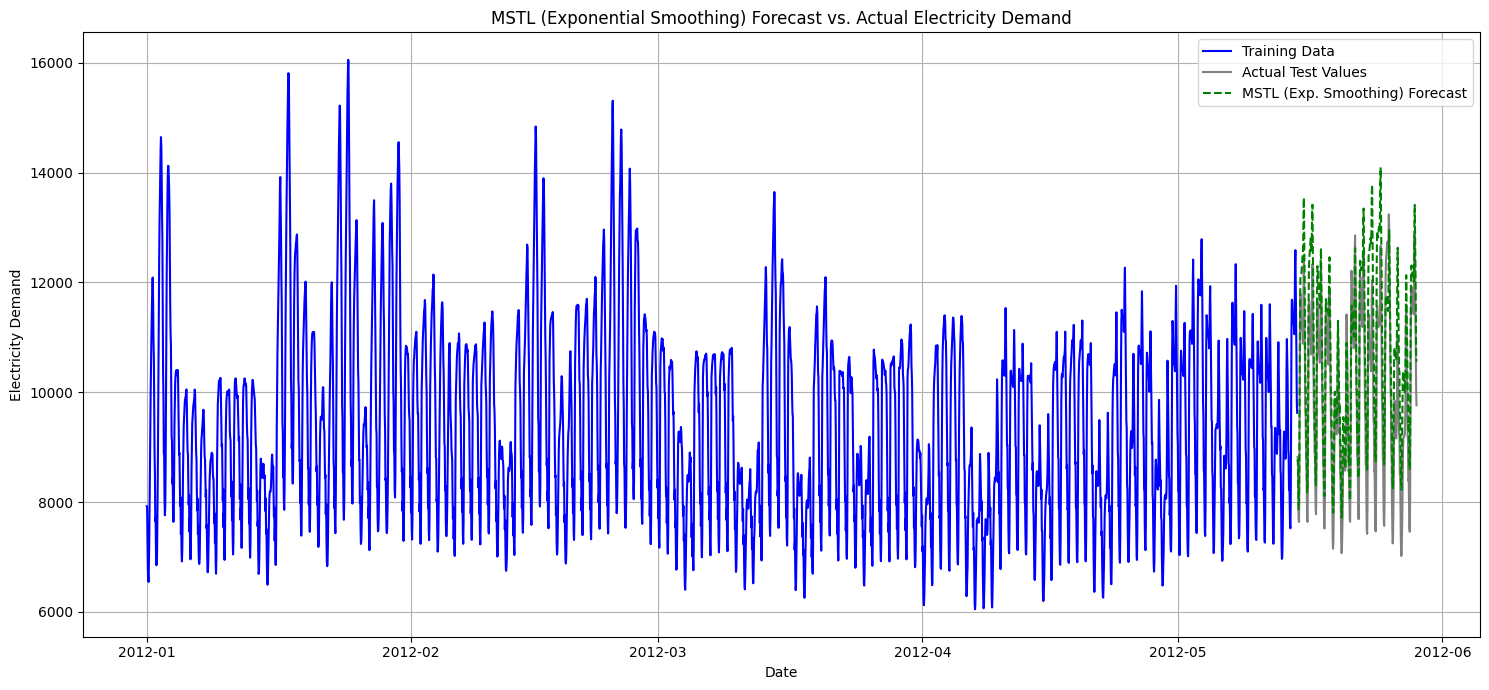

In [107]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['y'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['y'], label='Actual Test Values', color='gray')
plt.plot(final_forecast.index, final_forecast, label='MSTL (Exp. Smoothing) Forecast', color='green', linestyle='--')

plt.title('MSTL (Exponential Smoothing) Forecast vs. Actual Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Forecasting with ARIMA on MSTL Residuals

In [108]:
from statsmodels.tsa.arima.model import ARIMA

# Get the residuals from the MSTL decomposition on the training data
residuals_train = res.resid

# Define the p, d, q parameters to take any value between 0 and 2
p = d = q = range(0, 3)

# Generate all different combinations of p, d, q triplets
pdq_combinations = list(itertools.product(p, d, q))

print('ARIMA model parameter combinations:')
print('Non-seasonal (p,d,q):', pdq_combinations)

def evaluate_arima_model(data, order):
    # Evaluate an ARIMA model for a given order
    try:
        model = ARIMA(
            data,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            freq='h'
        )
        model_fit = model.fit() # Removed disp=False
        return model_fit.aic
    except Exception as e:
        print(f"Error with ARIMA{order}: {e}") # Uncommented for debugging
        return float('inf')


# Grid search for the best ARIMA parameters on residuals
best_aic = float('inf')
best_order = None

for order in pdq_combinations:
    aic = evaluate_arima_model(residuals_train, order)
    if aic < best_aic:
        best_aic = aic
        best_order = order
    print(f'ARIMA{order} AIC: {aic:.2f}')

print(f'Best ARIMA order for residuals: {best_order} with AIC: {best_aic:.2f}')

ARIMA model parameter combinations:
Non-seasonal (p,d,q): [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 2, 0), (0, 2, 1), (0, 2, 2), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 2, 0), (1, 2, 1), (1, 2, 2), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 2, 0), (2, 2, 1), (2, 2, 2)]
ARIMA(0, 0, 0) AIC: 51039.09
ARIMA(0, 0, 1) AIC: 46713.88
ARIMA(0, 0, 2) AIC: 43428.01
ARIMA(0, 1, 0) AIC: 39265.51
ARIMA(0, 1, 1) AIC: 37280.22
ARIMA(0, 1, 2) AIC: 36742.95
ARIMA(0, 2, 0) AIC: 37107.10
ARIMA(0, 2, 1) AIC: 37089.78
ARIMA(0, 2, 2) AIC: 36961.73
ARIMA(1, 0, 0) AIC: 39259.29
ARIMA(1, 0, 1) AIC: 37262.64
ARIMA(1, 0, 2) AIC: 36709.94
ARIMA(1, 1, 0) AIC: 36673.18
ARIMA(1, 1, 1) AIC: 36533.40
ARIMA(1, 1, 2) AIC: 36524.38
ARIMA(1, 2, 0) AIC: 37103.66
ARIMA(1, 2, 1) AIC: 37061.08
ARIMA(1, 2, 2) AIC: 36519.78
ARIMA(2, 0, 0) AIC: 36527.76
ARIMA(2, 0, 1) AIC: 36436.61
ARIMA(2, 0, 2) AIC: 36425.20
ARIMA(2, 1, 0) AIC: 36539.53
ARIMA(

### Fit ARIMA on Residuals and Generate Improved Forecast

In [109]:
# Fit ARIMA model to the training residuals with the best order
arima_residuals_model = ARIMA(
    residuals_train,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
    freq='h'
)
arima_residuals_model_fit = arima_residuals_model.fit()

# Forecast the residuals for the test period
forecasted_arima_residuals = arima_residuals_model_fit.forecast(steps=forecast_steps)
forecasted_arima_residuals.index = future_dates

# Combine the MSTL forecast (trend + seasonal) with the forecasted ARIMA residuals
final_forecast_improved = forecasted_trend + forecasted_seasonal_24 + forecasted_seasonal_168 + forecasted_seasonal_720 + forecasted_arima_residuals

print("Forecasted ARIMA Residuals (first 5):")
display(forecasted_arima_residuals.head())
print("Improved Final Forecast (first 5) combining MSTL and ARIMA residuals:")
display(final_forecast_improved.head())

Forecasted ARIMA Residuals (first 5):


,predicted_mean
ds,
2012-05-15 00:00:00,12.580855
2012-05-15 01:00:00,-2.884138
2012-05-15 02:00:00,-13.700304
2012-05-15 03:00:00,-21.059961
2012-05-15 04:00:00,-25.865747


Improved Final Forecast (first 5) combining MSTL and ARIMA residuals:


,0
2012-05-15 00:00:00,8757.311883
2012-05-15 01:00:00,8772.124577
2012-05-15 02:00:00,8235.516574
2012-05-15 03:00:00,7847.157309
2012-05-15 04:00:00,7902.213398


### Evaluate Improved Forecast Accuracy (MSTL + ARIMA Residuals)

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test_data['y']
y_pred_improved = final_forecast_improved

# Calculate MAE
mae_improved = mean_absolute_error(y_true, y_pred_improved)

# Calculate MSE
mse_improved = mean_squared_error(y_true, y_pred_improved)

# Calculate RMSE
rmse_improved = np.sqrt(mse_improved)

# Calculate MAPE (handling zero values in y_true)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100

mape_improved = mean_absolute_percentage_error(y_true, y_pred_improved)

print(f"Improved Mean Absolute Error (MAE): {mae_improved:.2f}")
print(f"Improved Mean Squared Error (MSE): {mse_improved:.2f}")
print(f"Improved Root Mean Squared Error (RMSE): {rmse_improved:.2f}")
print(f"Improved Mean Absolute Percentage Error (MAPE): {mape_improved:.2f}%")

# Compare with previous MSTL-only forecast accuracy (if available)
# Assuming `mae`, `mse`, `rmse`, `mape` variables from previous MSTL evaluation are still available in kernel state
print("\n--- Comparison with MSTL-only Forecast ---")
print(f"Original MSTL MAE: {mae:.2f}")
print(f"Original MSTL MSE: {mse:.2f}")
print(f"Original MSTL RMSE: {rmse:.2f}")
print(f"Original MSTL MAPE: {mape:.2f}%")

Improved Mean Absolute Error (MAE): 772.77
Improved Mean Squared Error (MSE): 829854.78
Improved Root Mean Squared Error (RMSE): 910.96
Improved Mean Absolute Percentage Error (MAPE): 7.89%

--- Comparison with MSTL-only Forecast ---
Original MSTL MAE: 781.94
Original MSTL MSE: 845264.69
Original MSTL RMSE: 919.38
Original MSTL MAPE: 7.99%


### Visualize MSTL Residuals vs. Forecasted ARIMA Residuals

This plot helps to see how well the ARIMA model is capturing the patterns within the residuals left by the MSTL decomposition.

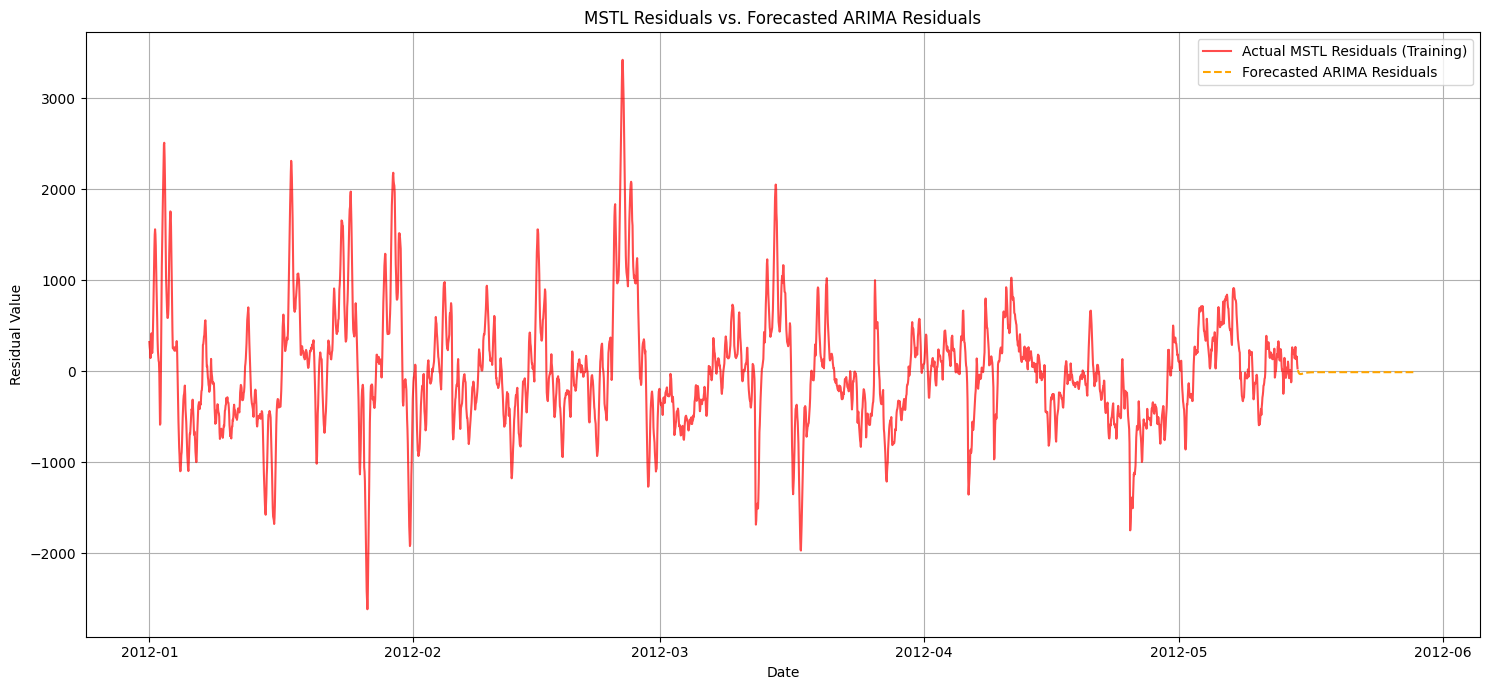

In [111]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, residuals_train, label='Actual MSTL Residuals (Training)', color='red', alpha=0.7)
plt.plot(test_data.index, forecasted_arima_residuals, label='Forecasted ARIMA Residuals', color='orange', linestyle='--')

# Optional: Also plot the actual test data and the final forecast for context
# plt.plot(test_data.index, test_data['y'], label='Actual Test Values', color='gray')
# plt.plot(final_forecast_improved.index, final_forecast_improved, label='Improved Final Forecast', color='purple', linestyle=':')

plt.title('MSTL Residuals vs. Forecasted ARIMA Residuals')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Plotting ACF and PACF of the *Final* Forecast Residuals

Let's examine the residuals of the `MSTL + ARIMA Residuals` model to see if there are any remaining patterns. Ideally, these should resemble white noise.

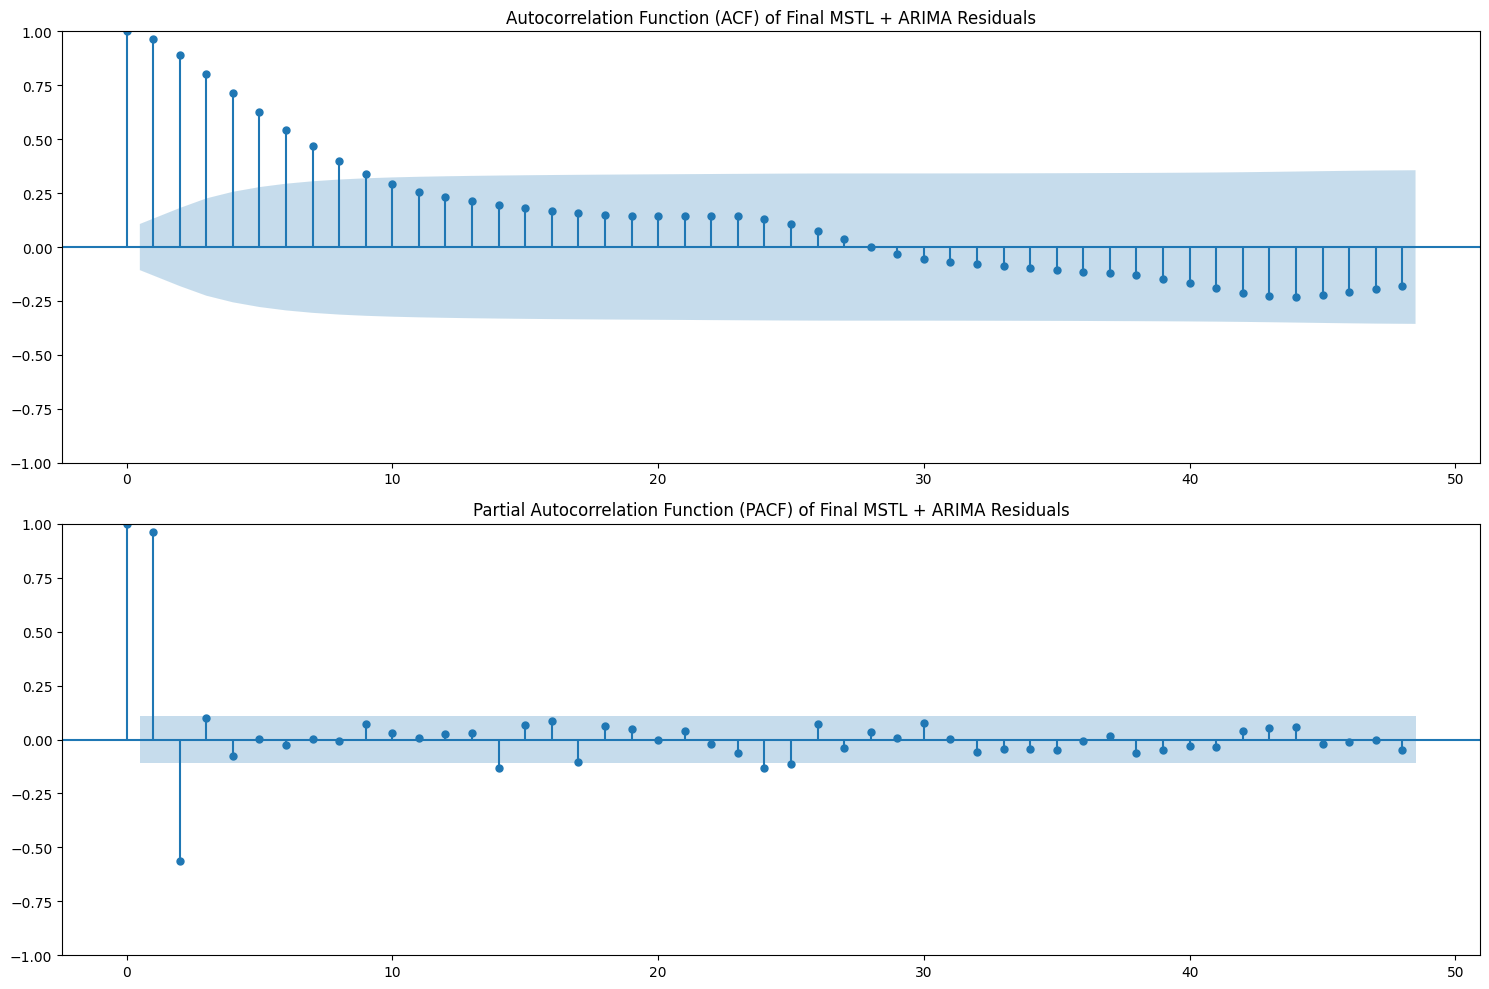

In [112]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Calculate the residuals of the MSTL + ARIMA improved forecast
mstl_arima_final_residuals = y_true - final_forecast_improved

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(mstl_arima_final_residuals, lags=48, ax=axes[0], title='Autocorrelation Function (ACF) of Final MSTL + ARIMA Residuals')
plot_pacf(mstl_arima_final_residuals, lags=48, ax=axes[1], title='Partial Autocorrelation Function (PACF) of Final MSTL + ARIMA Residuals')

plt.tight_layout()
plt.show()

### Histogram of Final MSTL + ARIMA Residuals

This histogram helps to visualize the distribution of the errors. Ideally, the residuals should be normally distributed around zero.

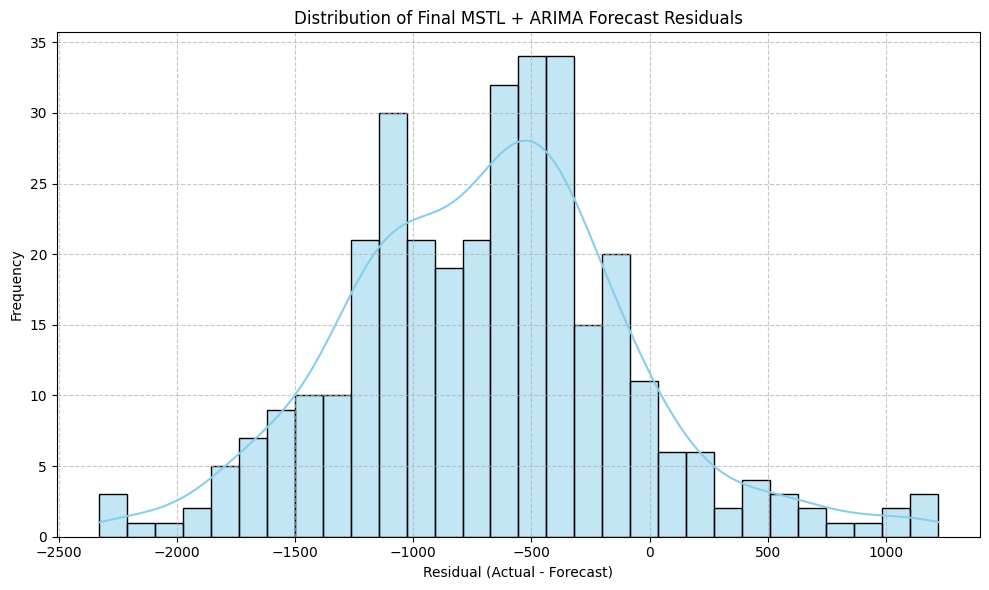

In [113]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(mstl_arima_final_residuals, kde=True, color='skyblue', bins=30)
plt.title('Distribution of Final MSTL + ARIMA Forecast Residuals')
plt.xlabel('Residual (Actual - Forecast)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualize ARIMA Forecast vs. Actual Values

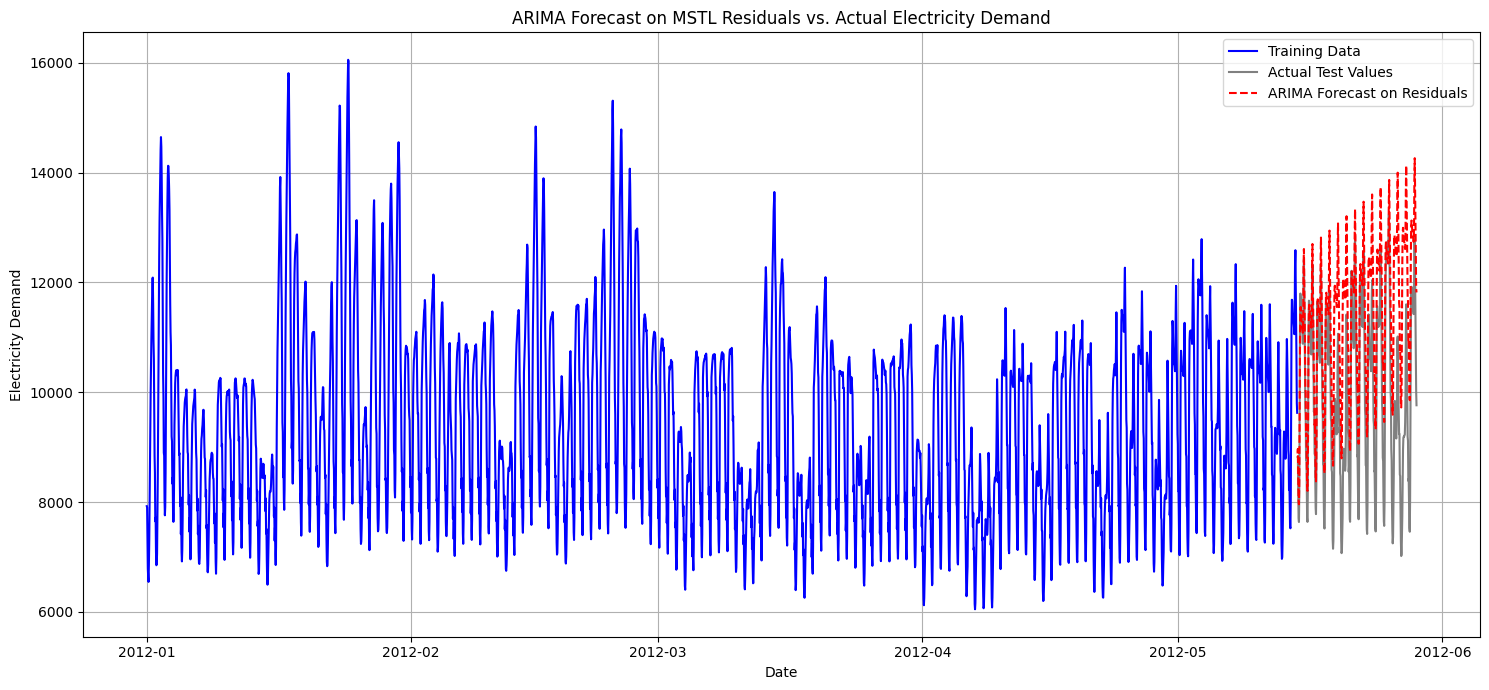

In [114]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['y'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['y'], label='Actual Test Values', color='gray')
plt.plot(sarima_forecast.index, sarima_forecast, label='ARIMA Forecast on Residuals', color='red', linestyle='--')

plt.title('ARIMA Forecast on MSTL Residuals vs. Actual Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning for Prophet Model

To further improve the Prophet model's performance, we'll perform a grid search to tune its hyperparameters. We will use Prophet's built-in cross-validation utility to evaluate different parameter combinations.

In [115]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

# Prophet expects columns named 'ds' and 'y'
prophet_train_df = train_data.reset_index()
prophet_train_df.columns = ['ds', 'y']

# Define the parameter grid to search
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1],
    'seasonality_prior_scale': [0.1, 1.0, 5.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

rmses = []  # To store RMSE for each parameter combination

print(f"Starting grid search for {len(all_params)} parameter combinations...")

# Loop through each parameter combination
for params in all_params:
    # print(f"\nEvaluating parameters: {params}") # Uncomment for verbose output
    m = Prophet(
        daily_seasonality=True,  # Keep as determined
        weekly_seasonality=True, # Keep as determined
        yearly_seasonality=False, # Keep as determined due to data limitation
        **params
    )
    m.fit(prophet_train_df)  # Fit model with current parameters

    # Perform cross-validation
    # initial: training period length (e.g., '60 days' or 2 months of data)
    # period: forecast horizon for each cross-validation cut-off (e.g., '7 days' or 1 week)
    # horizon: the length of the forecast period (e.g., '14 days' or 2 weeks, same as our test_data length)
    df_cv = cross_validation(m, initial='60 days', period='7 days', horizon='14 days', parallel='processes')

    # Calculate performance metrics
    df_p = performance_metrics(df_cv, metrics=['rmse'], rolling_window=1)
    current_rmse = df_p['rmse'].mean() # Use mean RMSE across all cross-validation folds

    rmses.append(current_rmse)

    # print(f"RMSE for current parameters: {current_rmse:.2f}") # Uncomment for verbose output

# Find the best parameters
idx = np.argmin(rmses)
best_params = all_params[idx]
best_rmse = rmses[idx]

print(f"\nBest Prophet parameters: {best_params}")
print(f"Best RMSE: {best_rmse:.2f}")


Starting grid search for 32 parameter combinations...


INFO:prophet:Making 9 forecasts with cutoffs between 2012-03-05 23:00:00 and 2012-04-30 23:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x78b4bba8ef00>
INFO:prophet:Making 9 forecasts with cutoffs between 2012-03-05 23:00:00 and 2012-04-30 23:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x78b4b946e9c0>
INFO:prophet:Making 9 forecasts with cutoffs between 2012-03-05 23:00:00 and 2012-04-30 23:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x78b4bba9f530>
INFO:prophet:Making 9 forecasts with cutoffs between 2012-03-05 23:00:00 and 2012-04-30 23:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x78b4bbab2d80>
INFO:prophet:Making 9 forecasts with cutoffs between 2012-03-05 23:00:00 and 2012-04-30 23:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.proc


Best Prophet parameters: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}
Best RMSE: 1006.51


### Retrain Prophet with Best Hyperparameters and Re-evaluate

Now, we'll retrain the Prophet model using the optimal hyperparameters found during the grid search and re-evaluate its performance.

In [116]:
# Retrain Prophet with the best parameters
model_prophet_tuned = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    **best_params
)
model_prophet_tuned.fit(prophet_train_df)

# Generate forecast with the tuned model
# The number of periods should match the length of the test data, with a frequency of 'h' (hourly)
future_tuned = model_prophet_tuned.make_future_dataframe(periods=len(test_data), freq='h', include_history=False)
prophet_forecast_tuned = model_prophet_tuned.predict(future_tuned)

# Align indices for evaluation
y_pred_prophet_tuned = prophet_forecast_tuned['yhat']
y_pred_prophet_tuned.index = test_data.index

# Evaluate the tuned model
# Assuming mean_absolute_error, mean_squared_error, mean_absolute_percentage_error are defined from earlier cells
prophet_mae_tuned = mean_absolute_error(test_data['y'], y_pred_prophet_tuned)
prophet_mse_tuned = mean_squared_error(test_data['y'], y_pred_prophet_tuned)
prophet_rmse_tuned = np.sqrt(prophet_mse_tuned)
prophet_mape_tuned = mean_absolute_percentage_error(test_data['y'], y_pred_prophet_tuned)

print(f"Tuned Prophet Mean Absolute Error (MAE): {prophet_mae_tuned:.2f}")
print(f"Tuned Prophet Mean Squared Error (MSE): {prophet_mse_tuned:.2f}")
print(f"Tuned Prophet Root Mean Squared Error (RMSE): {prophet_rmse_tuned:.2f}")
print(f"Tuned Prophet Mean Absolute Percentage Error (MAPE): {prophet_mape_tuned:.2f}%")

# Compare with previous Prophet model if prophet_mae is available
# if 'prophet_mae' in locals():
#    print("\n--- Comparison with previous Prophet model ---")
#    print(f"Original Prophet MAE: {prophet_mae:.2f}")
#    print(f"Tuned Prophet MAE: {prophet_mae_tuned:.2f}")


Tuned Prophet Mean Absolute Error (MAE): 1009.53
Tuned Prophet Mean Squared Error (MSE): 1484552.47
Tuned Prophet Root Mean Squared Error (RMSE): 1218.42
Tuned Prophet Mean Absolute Percentage Error (MAPE): 9.78%


### Visualize Tuned Prophet Forecast vs. Actual Values

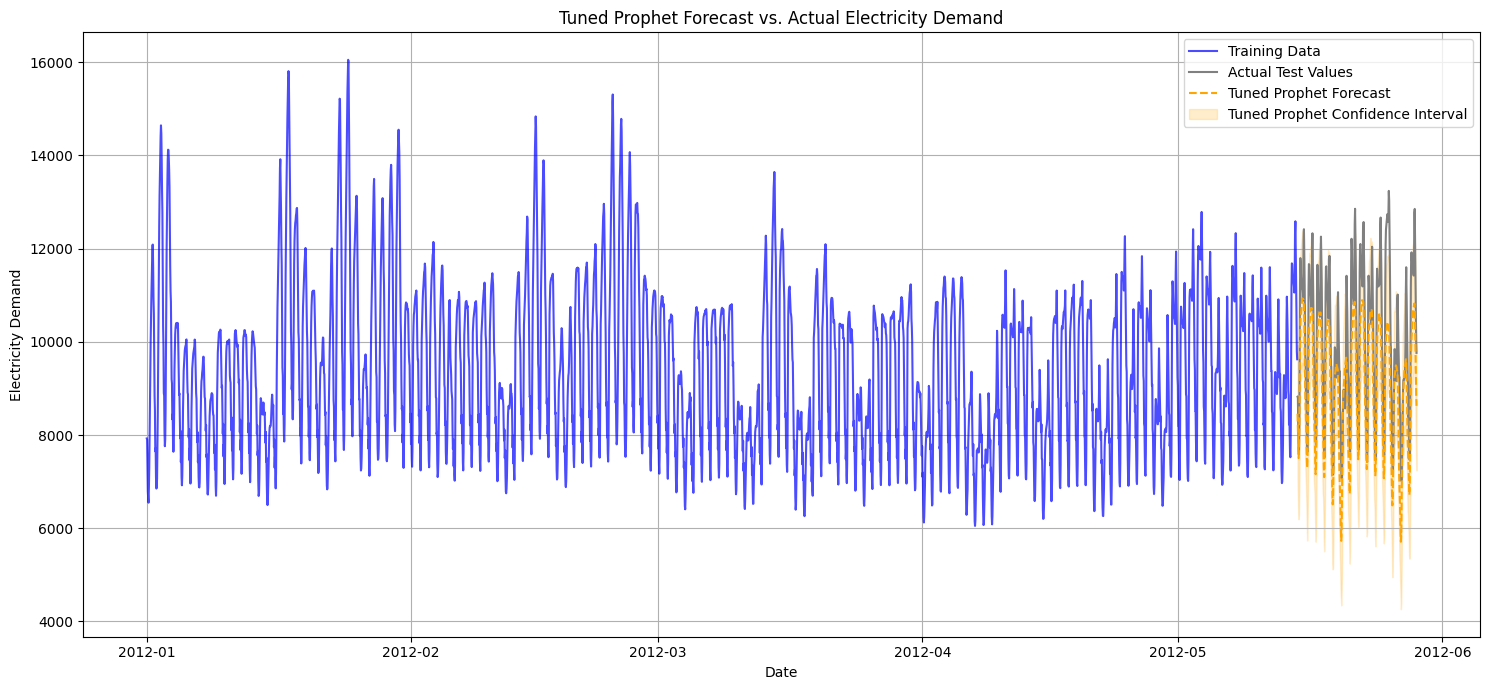

In [117]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['y'], label='Training Data', color='blue', alpha=0.7)
plt.plot(test_data.index, test_data['y'], label='Actual Test Values', color='gray')
plt.plot(prophet_forecast_tuned['ds'], prophet_forecast_tuned['yhat'], label='Tuned Prophet Forecast', color='orange', linestyle='--')
plt.fill_between(prophet_forecast_tuned['ds'], prophet_forecast_tuned['yhat_lower'], prophet_forecast_tuned['yhat_upper'], color='orange', alpha=0.2, label='Tuned Prophet Confidence Interval')

plt.title('Tuned Prophet Forecast vs. Actual Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Comprehensive Performance Comparison (including Tuned Prophet)

Let's update the comprehensive comparison to include the results from the tuned Prophet model.

### Plotting ACF and PACF of Tuned Prophet Residuals

Let's examine the residuals of the `Tuned Prophet` model to see if there are any remaining patterns. Ideally, these should resemble white noise.

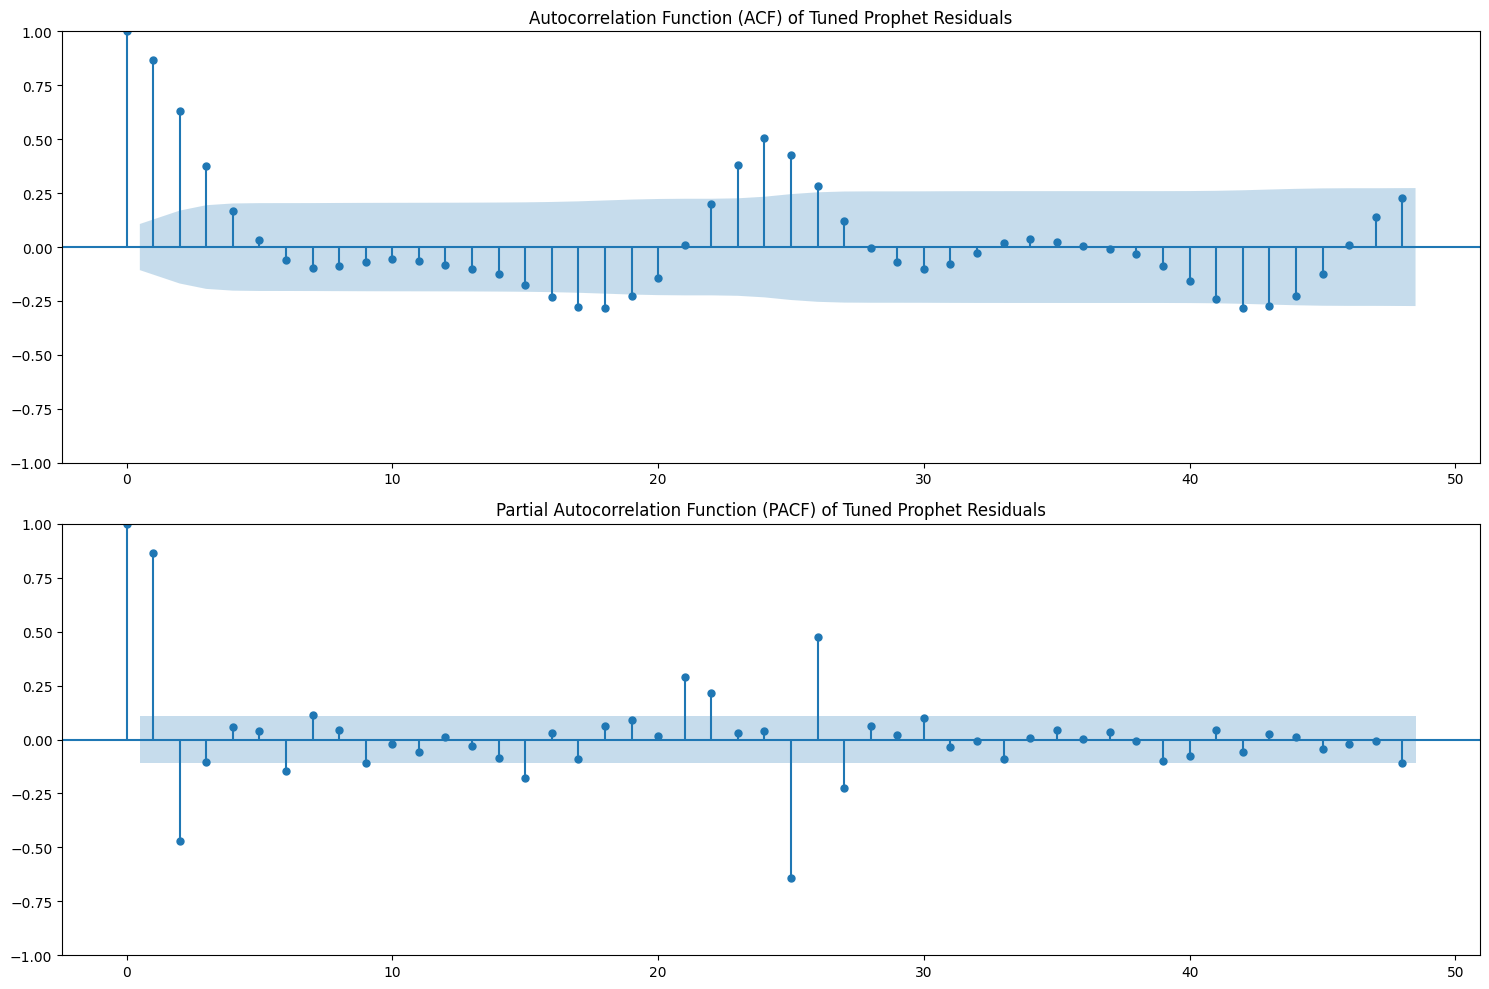

In [119]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Calculate the residuals of the Tuned Prophet forecast
prophet_tuned_residuals = y_true - y_pred_prophet_tuned

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(prophet_tuned_residuals, lags=48, ax=axes[0], title='Autocorrelation Function (ACF) of Tuned Prophet Residuals')
plot_pacf(prophet_tuned_residuals, lags=48, ax=axes[1], title='Partial Autocorrelation Function (PACF) of Tuned Prophet Residuals')

plt.tight_layout()
plt.show()

### Implementing Long Short-Term Memory (LSTM) Model

Given the complexity of the time series and the limitations of previous models, let's explore a Long Short-Term Memory (LSTM) neural network. LSTMs are well-suited for sequence prediction problems because they can learn long-term dependencies between time steps.

First, we need to prepare the data by scaling it and creating input sequences suitable for an LSTM model.

In [120]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Function to create sequences for LSTM
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i : (i + n_steps), 0])
        y.append(data[i + n_steps, 0])
    return np.array(X), np.array(y)

# Define the number of time steps (look-back period)
n_steps = 24  # Using 24 hours (1 day) as look-back period

# Create sequences for training and testing
X_train, y_train = create_sequences(train_scaled, n_steps)
X_test, y_test = create_sequences(test_scaled, n_steps)

# Reshape input to be 3D [samples, timesteps, features] for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3216, 24, 1)
y_train shape: (3216,)
X_test shape: (312, 24, 1)
y_test shape: (312,)


### Build and Train the LSTM Model

Now, we'll define the LSTM model architecture and train it using the prepared sequences.

In [121]:
# Define the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# Train the model
print("Training LSTM model...")
history = model_lstm.fit(
    X_train, y_train,
    epochs=50,  # Number of training epochs
    batch_size=32,
    verbose=1,
    validation_split=0.1 # Using a small validation split for monitoring
)

print("LSTM model training complete.")

Training LSTM model...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0591 - val_loss: 0.0136
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0104 - val_loss: 0.0100
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0058 - val_loss: 0.0065
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0042 - val_loss: 0.0045
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033 - val_loss: 0.0051
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0031 - val_loss: 0.0035
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - val_loss: 0.0034
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0020 - val_loss: 0.0025
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0018 - val_loss: 0.0023
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2

### Make Predictions and Evaluate LSTM Model

After training, we'll use the LSTM model to make predictions on the test set and evaluate its performance using our standard metrics.

In [122]:
# Make predictions
y_pred_lstm_scaled = model_lstm.predict(X_test)

# Inverse transform the predictions to original scale
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled)

# Align y_test (actual values) for evaluation by inverse transforming it
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Create a DataFrame for y_pred_lstm with proper index
# The first n_steps values of the test_data cannot be predicted due to the look-back window
lstm_forecast_dates = test_data.index[n_steps:]
y_pred_lstm_series = pd.Series(y_pred_lstm.flatten(), index=lstm_forecast_dates)

# Align y_true for evaluation (slice test_data to match the predicted length)
y_true_lstm = test_data['y'].iloc[n_steps:]

# Evaluate LSTM model
lstm_mae = mean_absolute_error(y_true_lstm, y_pred_lstm_series)
lstm_mse = mean_squared_error(y_true_lstm, y_pred_lstm_series)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mape = mean_absolute_percentage_error(y_true_lstm, y_pred_lstm_series)

print(f"LSTM Mean Absolute Error (MAE): {lstm_mae:.2f}")
print(f"LSTM Mean Squared Error (MSE): {lstm_mse:.2f}")
print(f"LSTM Root Mean Squared Error (RMSE): {lstm_rmse:.2f}")
print(f"LSTM Mean Absolute Percentage Error (MAPE): {lstm_mape:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
LSTM Mean Absolute Error (MAE): 339.71
LSTM Mean Squared Error (MSE): 246053.30
LSTM Root Mean Squared Error (RMSE): 496.04
LSTM Mean Absolute Percentage Error (MAPE): 3.34%


### Visualize LSTM Forecast vs. Actual Values

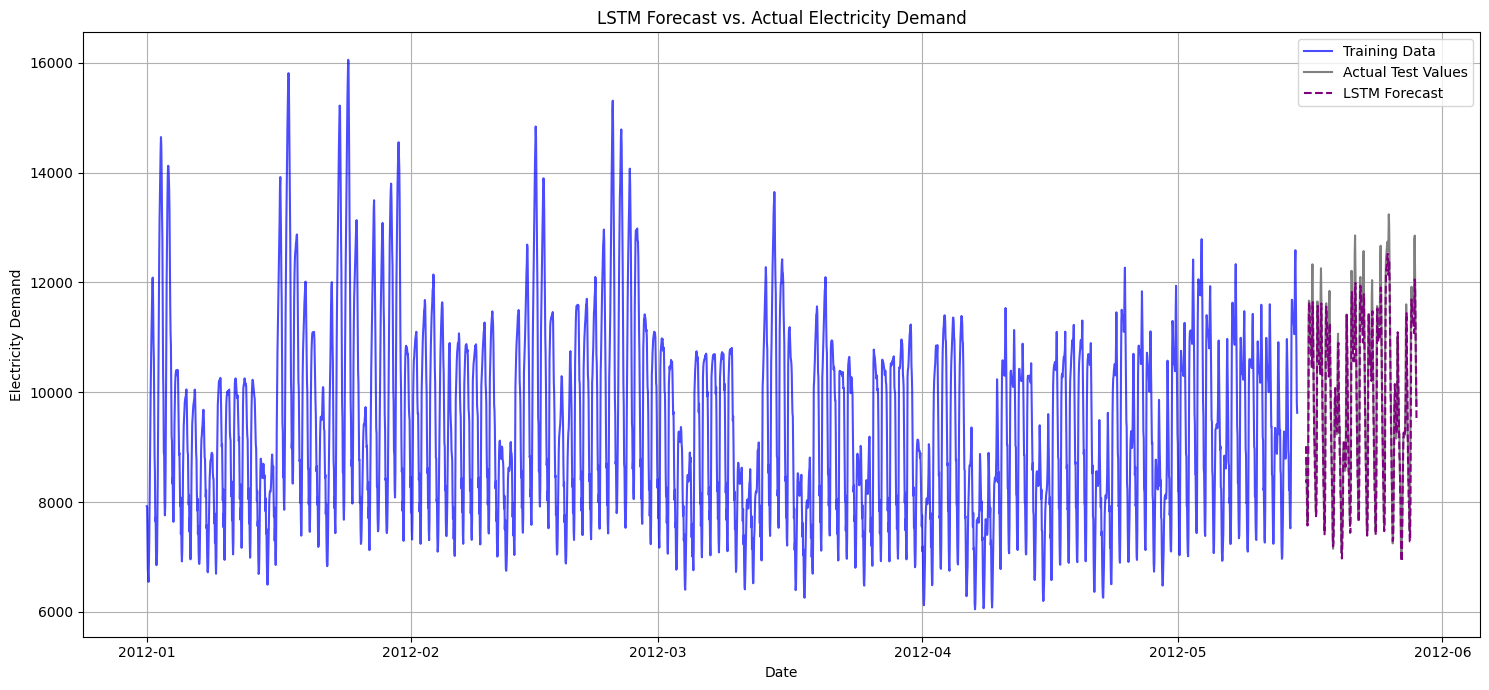

In [123]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['y'], label='Training Data', color='blue', alpha=0.7)
plt.plot(y_true_lstm.index, y_true_lstm, label='Actual Test Values', color='gray')
plt.plot(y_pred_lstm_series.index, y_pred_lstm_series, label='LSTM Forecast', color='purple', linestyle='--')

plt.title('LSTM Forecast vs. Actual Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Update Comprehensive Performance Comparison (including LSTM)

In [124]:
print('--- Comprehensive Performance Comparison ---\n')

print('--- MSTL (Exponential Smoothing) Forecast ---')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

print('\n--- MSTL + ARIMA Residuals Forecast ---')
print(f'MAE: {mae_improved:.2f}')
print(f'MSE: {mse_improved:.2f}')
print(f'RMSE: {rmse_improved:.2f}')
print(f'MAPE: {mape_improved:.2f}%')

print('\n--- SARIMA (on Original Data) Forecast ---')
print(f'MAE: {mae_sarima:.2f}')
print(f'MSE: {mse_sarima:.2f}')
print(f'RMSE: {rmse_sarima:.2f}')
print(f'MAPE: {mape_sarima:.2f}%')

print('\n--- Tuned Prophet Forecast ---')
print(f'MAE: {prophet_mae_tuned:.2f}')
print(f'MSE: {prophet_mse_tuned:.2f}')
print(f'RMSE: {prophet_rmse_tuned:.2f}')
print(f'MAPE: {prophet_mape_tuned:.2f}%')

print('\n--- LSTM Forecast ---')
print(f'MAE: {lstm_mae:.2f}')
print(f'MSE: {lstm_mse:.2f}')
print(f'RMSE: {lstm_rmse:.2f}')
print(f'MAPE: {lstm_mape:.2f}%')

print('\n--- Overall Conclusion ---')
best_model_name = 'MSTL (Exponential Smoothing)'
best_overall_mae = mae

if mae_improved < best_overall_mae:
    best_overall_mae = mae_improved
    best_model_name = 'MSTL + ARIMA Residuals'

if mae_sarima < best_overall_mae:
    best_overall_mae = mae_sarima
    best_model_name = 'SARIMA (on Original Data)'

if prophet_mae_tuned < best_overall_mae:
    best_overall_mae = prophet_mae_tuned
    best_model_name = 'Tuned Prophet'

if lstm_mae < best_overall_mae:
    best_overall_mae = lstm_mae
    best_model_name = 'LSTM'

print(f'The {best_model_name} approach currently provides the best overall accuracy with an MAE of {best_overall_mae:.2f}.')


--- Comprehensive Performance Comparison ---

--- MSTL (Exponential Smoothing) Forecast ---
MAE: 781.94
MSE: 845264.69
RMSE: 919.38
MAPE: 7.99%

--- MSTL + ARIMA Residuals Forecast ---
MAE: 772.77
MSE: 829854.78
RMSE: 910.96
MAPE: 7.89%

--- SARIMA (on Original Data) Forecast ---
MAE: 1368.81
MSE: 2822803.29
RMSE: 1680.12
MAPE: 14.76%

--- Tuned Prophet Forecast ---
MAE: 1009.53
MSE: 1484552.47
RMSE: 1218.42
MAPE: 9.78%

--- LSTM Forecast ---
MAE: 339.71
MSE: 246053.30
RMSE: 496.04
MAPE: 3.34%

--- Overall Conclusion ---
The LSTM approach currently provides the best overall accuracy with an MAE of 339.71.
